## Preparación de datos

In [1]:
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

load_dotenv()
usuario = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
base_datos = os.getenv("DB_NAME")

In [2]:
csv_file = "ventas_tienda_online.csv"
df = pd.read_csv(csv_file, encoding="latin1")
df = df.map(lambda x: x.encode("latin1").decode("utf-8") if isinstance(x, str) else x)

print("Datos originales:")
df.head()

Datos originales:


,order_id,purchase_date,customer_id,customer_gender,customer_age,product_category,product_name,product_price,quantity,order_total,payment_method,shipping_region
0,96,8/12/23,822,Masculino,18.0,Accesorios,Bolso,90.72,3,272.16,PayPal,Oeste
1,142,3/09/23,139,Femenino,18.0,Ropa,Pantalón,131.68,3,395.04,PayPal,Oeste
2,216,24/08/23,86,Masculino,18.0,Calzado,Zapatillas,36.18,1,36.18,Transferencia bancaria,Este
3,235,15/03/23,473,Masculino,18.0,Ropa,Vestido,78.55,5,392.75,Transferencia bancaria,Centro
4,284,24/04/23,113,Masculino,18.0,Calzado,Sandalias,116.37,1,116.37,Tarjeta de crédito,Norte


In [3]:
df = df.drop_duplicates()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Desconocido")
    else:
        df[col] = df[col].fillna(0)

df["order_id"] = df["order_id"].astype(int)
df["customer_id"] = df["customer_id"].astype(int)
df["customer_age"] = df["customer_age"].astype(int)
df["product_price"] = df["product_price"].astype(float)
df["quantity"] = df["quantity"].astype(int)
df["order_total"] = df["order_total"].astype(float)
df["purchase_date"] = pd.to_datetime(df["purchase_date"], format="%d/%m/%y", errors="coerce")

df.dtypes

order_id                     int64
purchase_date       datetime64[ns]
customer_id                  int64
customer_gender             object
customer_age                 int64
product_category            object
product_name                object
product_price              float64
quantity                     int64
order_total                float64
payment_method              object
shipping_region             object
dtype: object

### Revisar duplicados y crear dimensiones

In [4]:
customer_duplicates = df.duplicated(subset=['customer_id'], keep=False)
if customer_duplicates.any():
    print(f"  {customer_duplicates.sum()} customer_id duplicados")
    df[df.duplicated(subset=['customer_id'], keep=False)].head()

dim_clientes = df[["customer_id", "customer_gender", "customer_age"]].drop_duplicates(subset=['customer_id'])
dim_productos = df[["product_category", "product_name"]].drop_duplicates().reset_index(drop=True)
dim_productos["product_id"] = dim_productos.index + 1

dim_fechas = df[["purchase_date"]].drop_duplicates().reset_index(drop=True)
dim_fechas["date_id"] = dim_fechas.index + 1
dim_fechas["anio"] = dim_fechas["purchase_date"].dt.year
dim_fechas["mes"] = dim_fechas["purchase_date"].dt.month
dim_fechas["dia"] = dim_fechas["purchase_date"].dt.day

metodos_pago = df[["payment_method"]].drop_duplicates().reset_index(drop=True)
metodos_pago["payment_id"] = metodos_pago.index + 1

regiones = df[["shipping_region"]].drop_duplicates().reset_index(drop=True)
regiones["region_id"] = regiones.index + 1

fact_ventas = df.merge(dim_productos, on=["product_category", "product_name"]) \
                .merge(dim_fechas, on="purchase_date") \
                .merge(metodos_pago, on="payment_method") \
                .merge(regiones, on="shipping_region")

fact_ventas = fact_ventas[[
    "order_id", "date_id", "customer_id", "product_id", "payment_id", "region_id",
    "product_price", "quantity", "order_total"
]]

fact_ventas.head()

  9999 customer_id duplicados


,order_id,date_id,customer_id,product_id,payment_id,region_id,product_price,quantity,order_total
0,96,1,822,1,1,1,90.72,3,272.16
1,142,2,139,2,1,1,131.68,3,395.04
2,216,3,86,3,2,2,36.18,1,36.18
3,235,4,473,4,2,3,78.55,5,392.75
4,284,5,113,5,3,4,116.37,1,116.37


In [5]:
engine = create_engine(f"mysql+pymysql://{usuario}:{password}@{host}/{base_datos}")

In [6]:
def drop_all_tables():
    with engine.begin() as conn:
        conn.execute(text("SET FOREIGN_KEY_CHECKS = 0"))
        tables = ['fact_ventas', 'clientes', 'productos', 'fechas', 'metodos_pago', 'regiones']
        for table in tables:
            conn.execute(text(f"DROP TABLE IF EXISTS {table}"))
        conn.execute(text("SET FOREIGN_KEY_CHECKS = 1"))

drop_all_tables()

In [7]:
def create_star_schema():
    dim_clientes.to_sql("clientes", con=engine, if_exists='replace', index=False)
    dim_productos.to_sql("productos", con=engine, if_exists='replace', index=False)
    dim_fechas.to_sql("fechas", con=engine, if_exists='replace', index=False)
    metodos_pago.to_sql("metodos_pago", con=engine, if_exists='replace', index=False)
    regiones.to_sql("regiones", con=engine, if_exists='replace', index=False)
    fact_ventas.to_sql("fact_ventas", con=engine, if_exists='replace', index=False)

    with engine.begin() as conn:
        conn.execute(text("ALTER TABLE clientes ADD PRIMARY KEY (customer_id)"))
        conn.execute(text("ALTER TABLE productos ADD PRIMARY KEY (product_id)"))
        conn.execute(text("ALTER TABLE fechas ADD PRIMARY KEY (date_id)"))
        conn.execute(text("ALTER TABLE metodos_pago ADD PRIMARY KEY (payment_id)"))
        conn.execute(text("ALTER TABLE regiones ADD PRIMARY KEY (region_id)"))
        conn.execute(text("ALTER TABLE fact_ventas ADD FOREIGN KEY (customer_id) REFERENCES clientes(customer_id)"))
        conn.execute(text("ALTER TABLE fact_ventas ADD FOREIGN KEY (product_id) REFERENCES productos(product_id)"))
        conn.execute(text("ALTER TABLE fact_ventas ADD FOREIGN KEY (date_id) REFERENCES fechas(date_id)"))
        conn.execute(text("ALTER TABLE fact_ventas ADD FOREIGN KEY (payment_id) REFERENCES metodos_pago(payment_id)"))
        conn.execute(text("ALTER TABLE fact_ventas ADD FOREIGN KEY (region_id) REFERENCES regiones(region_id)"))

create_star_schema()


In [8]:
with engine.begin() as conn:
    tables = ['clientes', 'productos', 'fechas', 'metodos_pago', 'regiones', 'fact_ventas']
    for table in tables:
        result = conn.execute(text(f"SELECT COUNT(*) FROM {table}"))
        print(f"{table}: {result.scalar()} registros")

clientes: 1000 registros
productos: 20 registros
fechas: 365 registros
metodos_pago: 5 registros
regiones: 5 registros
fact_ventas: 10000 registros


## Análisis exploratorio

In [9]:
query = """
SELECT f.order_id, f.product_price, f.quantity, f.order_total,
       p.product_category, p.product_name,
       r.shipping_region,
       c.customer_age, c.customer_gender,
       d.purchase_date
FROM fact_ventas f
JOIN productos p ON f.product_id = p.product_id
JOIN regiones r ON f.region_id = r.region_id
JOIN clientes c ON f.customer_id = c.customer_id
JOIN fechas d ON f.date_id = d.date_id
"""
df = pd.read_sql(query, engine)
df.head()

,order_id,product_price,quantity,order_total,product_category,product_name,shipping_region,customer_age,customer_gender,purchase_date
0,3709,112.13,3,336.39,Accesorios,Bolso,Sur,18,Femenino,2023-12-25
1,1632,96.19,1,96.19,Accesorios,Bolso,Sur,19,Femenino,2023-01-18
2,2172,194.74,3,584.22,Accesorios,Bolso,Sur,19,Femenino,2023-06-03
3,1129,76.56,1,76.56,Accesorios,Bolso,Sur,21,Masculino,2023-08-11
4,4706,135.15,1,135.15,Accesorios,Bolso,Sur,21,Femenino,2023-10-06


In [10]:
estadisticas = df[["product_price", "quantity", "order_total", "customer_age"]].agg(
    ["mean", "median"]
)
estadisticas = estadisticas.rename(index={"mean": "Media", "median": "Mediana"})

modas = df[["product_price", "quantity", "order_total", "customer_age"]].mode().iloc[0]
modas.name = "Moda"

tabla_estadisticas = pd.concat([estadisticas, modas.to_frame().T])
tabla_estadisticas


,product_price,quantity,order_total,customer_age
Media,104.875959,2.9995,314.509017,22.9574
Mediana,104.840000,3.0000,254.840000,21.0000
Moda,17.970000,2.0000,150.200000,18.0000


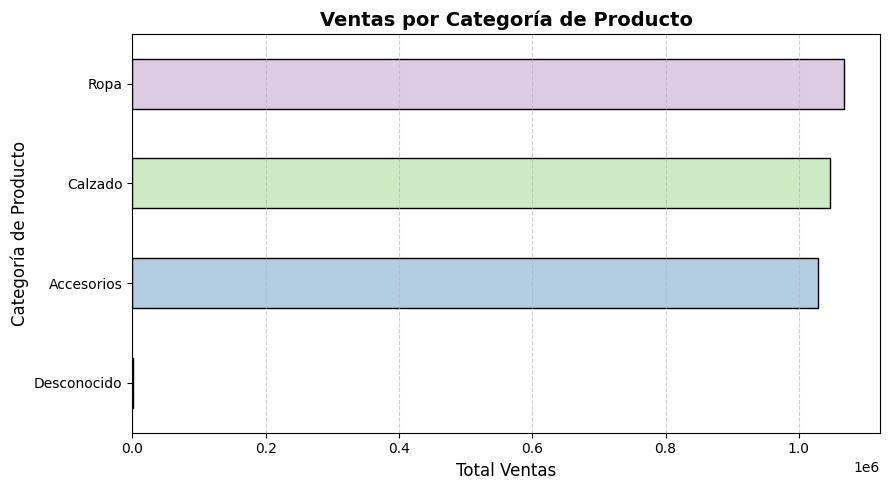

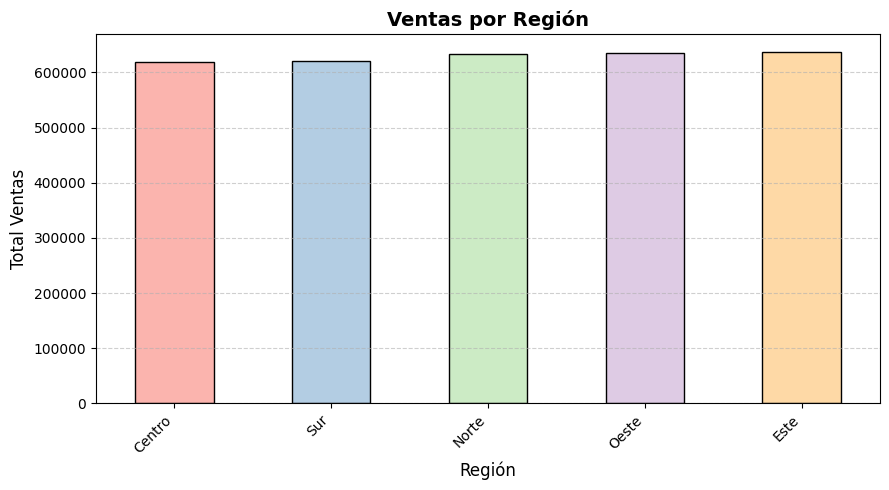

In [ ]:
import matplotlib.pyplot as plt

colores_pastel = plt.cm.Pastel1.colors

ventas_categoria = df.groupby("product_category")["order_total"].sum().sort_values()

plt.figure(figsize=(9,5))
ventas_categoria.plot(
    kind="barh", 
    color=colores_pastel, 
    edgecolor="black"
)
plt.title("Ventas por Categoría de Producto", fontsize=14, fontweight="bold")
plt.xlabel("Total Ventas", fontsize=12)
plt.ylabel("Categoría de Producto", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

ventas_region = df.groupby("shipping_region")["order_total"].sum().sort_values()

plt.figure(figsize=(9,5))
ventas_region.plot(
    kind="bar", 
    color=colores_pastel, 
    edgecolor="black"
)
plt.title("Ventas por Región", fontsize=14, fontweight="bold")
plt.xlabel("Región", fontsize=12)
plt.ylabel("Total Ventas", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Análisis de tendencias

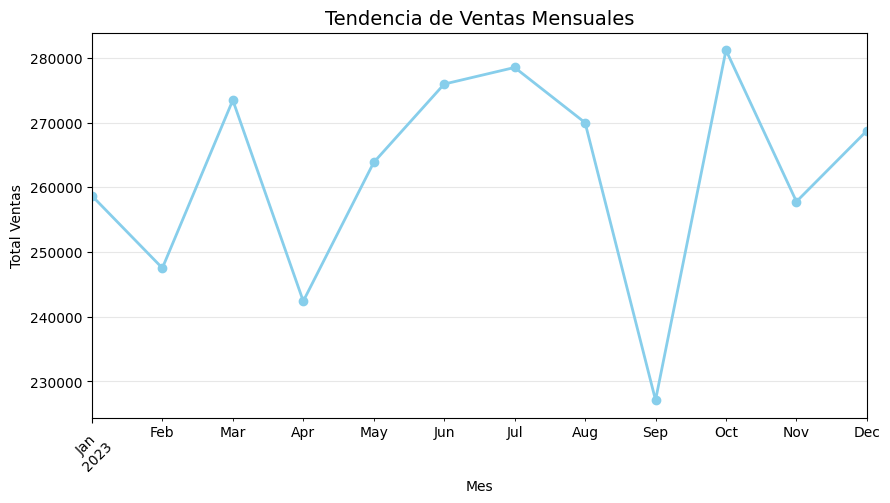

Top 3 meses con más ventas:


,Fecha,Total
0,2023-10,"281,186.76"
1,2023-07,"278,505.31"
2,2023-06,"275,939.29"


Top 3 meses con menos ventas:


,Fecha,Total
0,2023-09,"227,103.47"
1,2023-04,"242,391.66"
2,2023-02,"247,510.02"


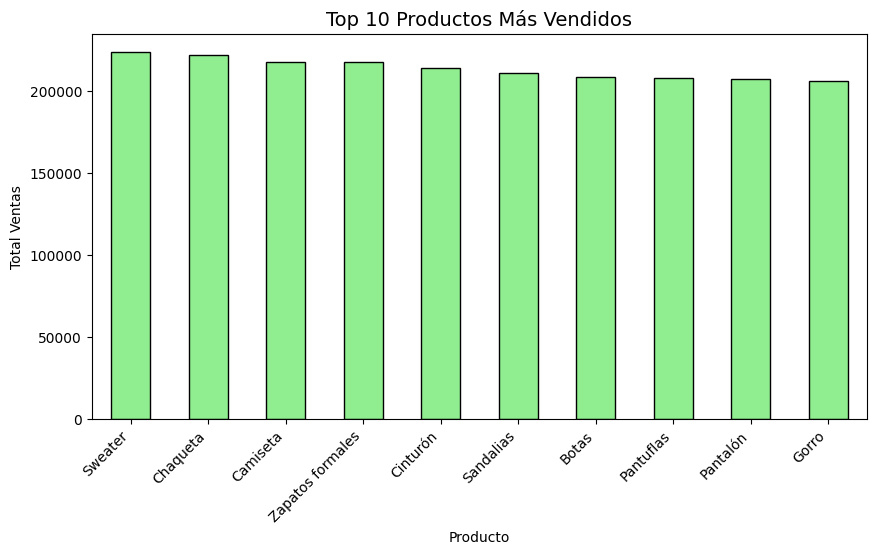

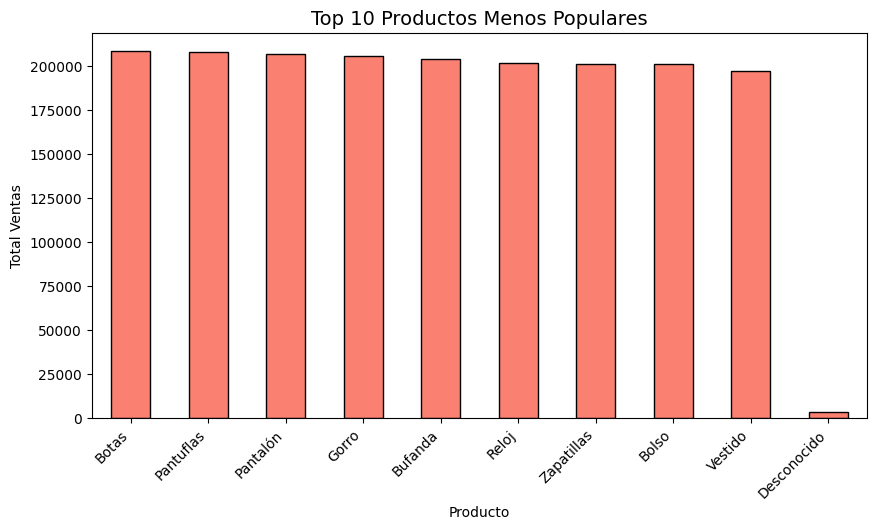

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


df["purchase_date"] = pd.to_datetime(df["purchase_date"])

ventas_mes = df.groupby(df["purchase_date"].dt.to_period("M"))["order_total"].sum()

plt.figure(figsize=(10,5))
ventas_mes.plot(kind="line", marker="o", color="skyblue", linewidth=2)
plt.title("Tendencia de Ventas Mensuales", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Total Ventas")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

top_3_meses = ventas_mes.sort_values(ascending=False).head(3).reset_index()
top_3_meses.columns = ["Fecha", "Total"]  
print("Top 3 meses con más ventas:")
display(top_3_meses.style.set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#f7d6d0'), ('color', 'black'), ('font-weight', 'bold')]},
     {'selector': 'td', 'props': [('padding', '5px')]}]
).format({"Total": "{:,.2f}"}))  

bottom_3_meses = ventas_mes.sort_values().head(3).reset_index()
bottom_3_meses.columns = ["Fecha", "Total"]
print("Top 3 meses con menos ventas:")
display(bottom_3_meses.style.set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#d0e7f7'), ('color', 'black'), ('font-weight', 'bold')]},
     {'selector': 'td', 'props': [('padding', '5px')]}]
).format({"Total": "{:,.2f}"}))

productos_ventas = df.groupby("product_name")["order_total"].sum().sort_values(ascending=False)

top_10 = productos_ventas.head(10)
plt.figure(figsize=(10,5))
top_10.plot(kind="bar", color="lightgreen", edgecolor="black")
plt.title("Top 10 Productos Más Vendidos", fontsize=14)
plt.xlabel("Producto")
plt.ylabel("Total Ventas")
plt.xticks(rotation=45, ha="right")
plt.show()

bottom_10 = productos_ventas.tail(10)
plt.figure(figsize=(10,5))
bottom_10.plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Top 10 Productos Menos Populares", fontsize=14)
plt.xlabel("Producto")
plt.ylabel("Total Ventas")
plt.xticks(rotation=45, ha="right")
plt.show()


## Segmentación de clientes

In [12]:
import pandas as pd
from IPython.display import display

bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ["<18","18-25","26-35","36-45","46-55","56-65", "65+"]
df["rango_edad"] = pd.cut(df["customer_age"], bins=bins, labels=labels, right=False)

resumen_edad = df.groupby("rango_edad").agg(
    total_ventas = ("order_total", "sum"),
    promedio_venta = ("order_total", "mean"),
    cantidad_pedidos = ("order_total", "count")
).reset_index()

display(resumen_edad.style.set_table_styles(
    [
        {'selector': 'th', 'props': [('background-color', '#f7d6d0'), ('color', 'black'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('padding', '5px')]}
    ]
).format({
    "total_ventas": "{:,.2f}",
    "promedio_venta": "{:,.2f}",
    "cantidad_pedidos": "{:,.0f}"
}).set_caption("Resumen de Ventas por Rango de Edad"))


C:\Users\Roberto\AppData\Local\Temp\ipykernel_21100\3520168903.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_edad = df.groupby("rango_edad").agg(


,rango_edad,total_ventas,promedio_venta,cantidad_pedidos
0,<18,0.00,nan,0
1,18-25,"2,268,368.03",315.97,"7,179"
2,26-35,"744,763.24",310.06,"2,402"
3,36-45,"113,098.21",318.59,355
4,46-55,"15,291.18",283.17,54
5,56-65,"3,196.13",355.13,9
6,65+,373.38,373.38,1


C:\Users\Roberto\AppData\Local\Temp\ipykernel_21100\2814646287.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


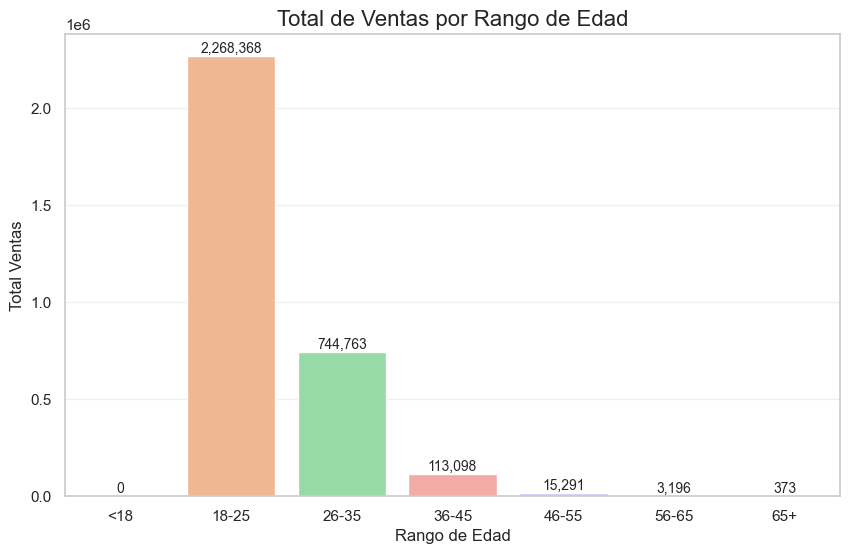

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

sns.barplot(
    x="rango_edad", 
    y="total_ventas", 
    data=resumen_edad, 
    palette="pastel"
)

plt.title("Total de Ventas por Rango de Edad", fontsize=16)
plt.xlabel("Rango de Edad")
plt.ylabel("Total Ventas")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for index, row in resumen_edad.iterrows():
    plt.text(index, row.total_ventas + 1000, f"{row.total_ventas:,.0f}", 
             ha='center', va='bottom', fontsize=10)

plt.show()

In [14]:
resumen_genero = df.groupby("customer_gender").agg(
    total_ventas = ("order_total", "sum"),
    promedio_venta = ("order_total", "mean"),
    cantidad_pedidos = ("order_total", "count")
).reset_index()

display(resumen_genero.style.set_table_styles(
    [
        {'selector': 'th', 'props': [('background-color', '#d0e7f7'), ('color', 'black'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('padding', '5px')]}
    ]
).format({
    "total_ventas": "{:,.2f}",
    "promedio_venta": "{:,.2f}",
    "cantidad_pedidos": "{:,.0f}"
}).set_caption("Resumen de Ventas por Género"))


,customer_gender,total_ventas,promedio_venta,cantidad_pedidos
0,Femenino,"1,576,233.49",314.12,"5,018"
1,Masculino,"1,568,856.68",314.90,"4,982"


C:\Users\Roberto\AppData\Local\Temp\ipykernel_21100\1716486342.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
c:\Users\Roberto\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


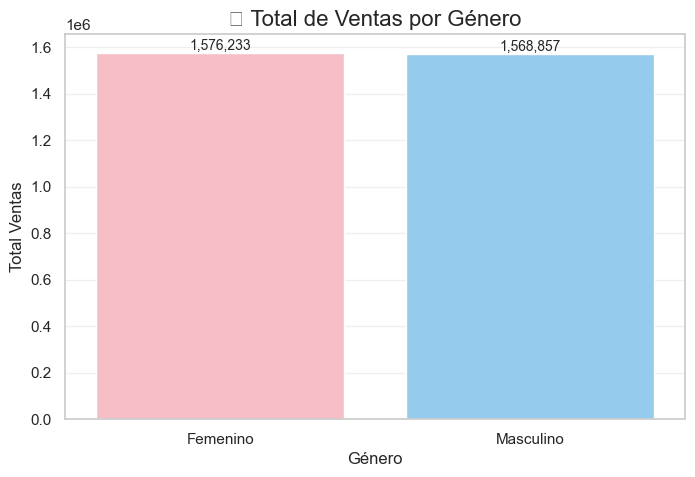

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))

sns.barplot(
    x="customer_gender",
    y="total_ventas",
    data=resumen_genero,
    palette=["#FFB6C1", "#87CEFA"]  
)

plt.title("Total de Ventas por Género", fontsize=16)
plt.xlabel("Género")
plt.ylabel("Total Ventas")
plt.grid(axis="y", alpha=0.3)

for index, row in resumen_genero.iterrows():
    plt.text(index, row.total_ventas + 1000, f"{row.total_ventas:,.0f}", 
             ha='center', va='bottom', fontsize=10)

plt.show()

# Análisis de correlación

5a. Investigar si existe una relación entre el total de la orden y la edad del cliente.

5.a Correlación entre Edad del Cliente y Total de la Orden 
Correlación de Pearson: nan  (p-valor: nan )
Correlación de Spearman: nan  (p-valor: nan )


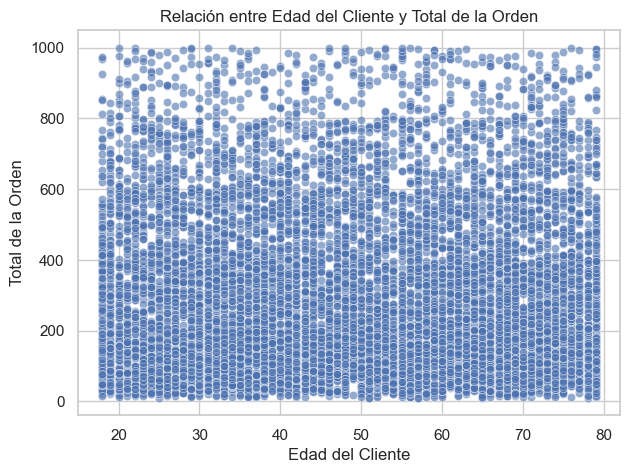

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr



ages = df["customer_age"]
totals = df["order_total"]


pearson_corr, pearson_p = pearsonr(ages, totals)
spearman_corr, spearman_p = spearmanr(ages, totals)

print("5.a Correlación entre Edad del Cliente y Total de la Orden ")
print("Correlación de Pearson:", pearson_corr, " (p-valor:", pearson_p, ")")
print("Correlación de Spearman:", spearman_corr, " (p-valor:", spearman_p, ")")


plt.figure(figsize=(7,5))
sns.scatterplot(x=ages, y=totals, alpha=0.6)
plt.title("Relación entre Edad del Cliente y Total de la Orden")
plt.xlabel("Edad del Cliente")
plt.ylabel("Total de la Orden")
plt.grid(True)
plt.show()


5b. Examinar si hay una correlación entre la categoría del producto y el método de pago preferido. 


=== 5.b Tabla de contingencia ===
 payment_method    Efectivo  PayPal  Tarjeta de crédito  Transferencia bancaria
product_category                                                              
Accesorios             822     809                 844                     837
Calzado                854     815                 788                     861
Ropa                   871     833                 816                     848

Índice V de Cramer: 0.014320734690893394


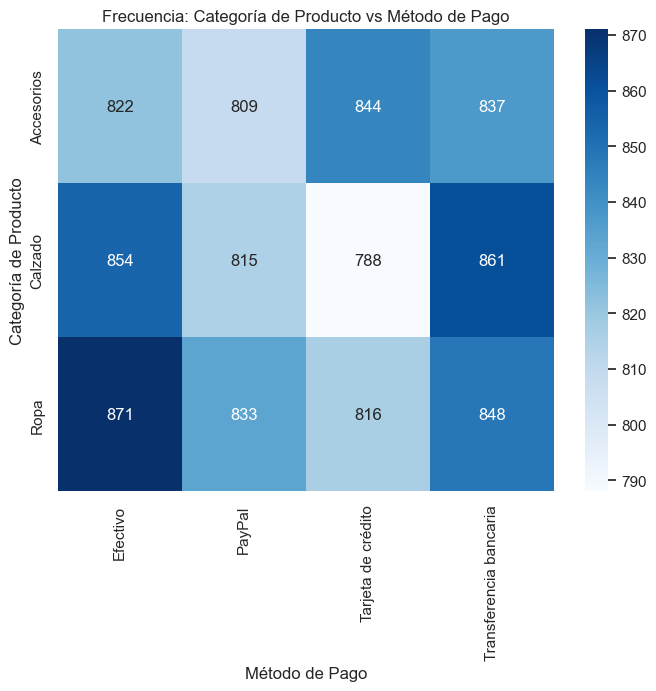

In [20]:
contingency = pd.crosstab(df["product_category"], df["payment_method"])
print("\n=== 5.b Tabla de contingencia ===\n", contingency)

# Cálculo del V de Cramer
chi2 = ((contingency - contingency.mean())**2 / contingency.mean()).to_numpy().sum()
n = contingency.to_numpy().sum()
phi2 = chi2 / n
r, k = contingency.shape
cramers_v = np.sqrt(phi2 / min(k-1, r-1))

print("\nÍndice V de Cramer:", cramers_v)

# Heatmap de frecuencias
plt.figure(figsize=(8,6))
sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues")
plt.title("Frecuencia: Categoría de Producto vs Método de Pago")
plt.ylabel("Categoría de Producto")
plt.xlabel("Método de Pago")
plt.show()

# Visualización de datos

Crear al menos siete gráficos diferentes (por ejemplo, gráfico de barras,
gráfico de dispersión, gráfico de líneas) para representar los hallazgos
más importantes.

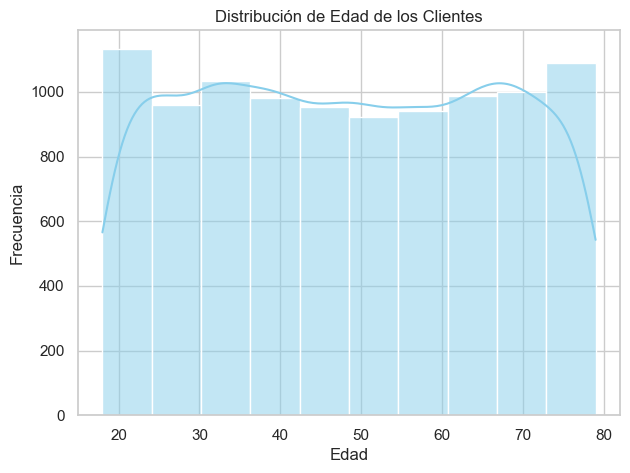

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución de edades de los clientes (histograma)

plt.figure(figsize=(7,5))
sns.histplot(df["customer_age"], bins=10, kde=True, color="skyblue")
plt.title("Distribución de Edad de los Clientes")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()



C:\Users\Roberto\AppData\Local\Temp\ipykernel_21100\4282417710.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_category.index, y=sales_by_category.values, palette="viridis")


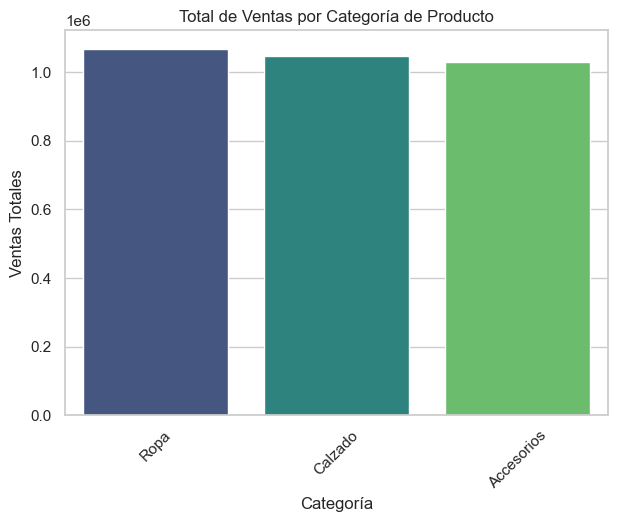

In [22]:
# Total de ventas por categoría de producto (barras)
plt.figure(figsize=(7,5))
sales_by_category = df.groupby("product_category")["order_total"].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_category.index, y=sales_by_category.values, palette="viridis")
plt.title("Total de Ventas por Categoría de Producto")
plt.xlabel("Categoría")
plt.ylabel("Ventas Totales")
plt.xticks(rotation=45)
plt.show()


C:\Users\Roberto\AppData\Local\Temp\ipykernel_21100\2392211983.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_payment.index, y=sales_by_payment.values, palette="Set2")


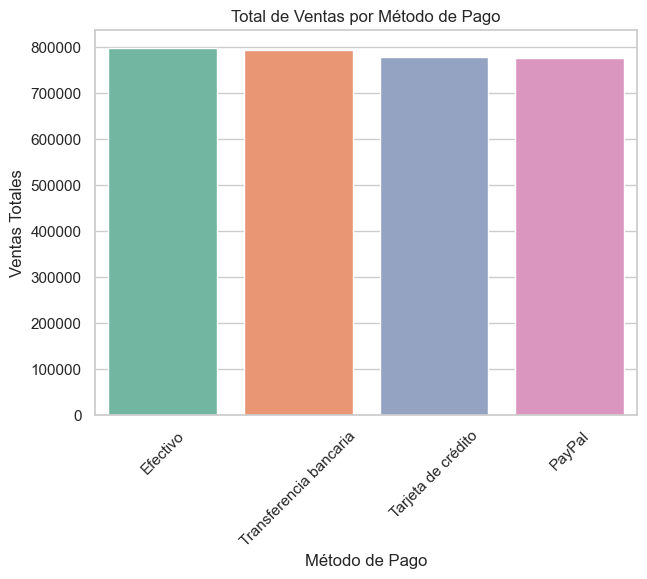

In [23]:
# Total de ventas por método de pago (barras)

plt.figure(figsize=(7,5))
sales_by_payment = df.groupby("payment_method")["order_total"].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_payment.index, y=sales_by_payment.values, palette="Set2")
plt.title("Total de Ventas por Método de Pago")
plt.xlabel("Método de Pago")
plt.ylabel("Ventas Totales")
plt.xticks(rotation=45)
plt.show()

C:\Users\Roberto\AppData\Local\Temp\ipykernel_21100\1838708976.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quantity_by_category.values, y=quantity_by_category.index, palette="coolwarm")


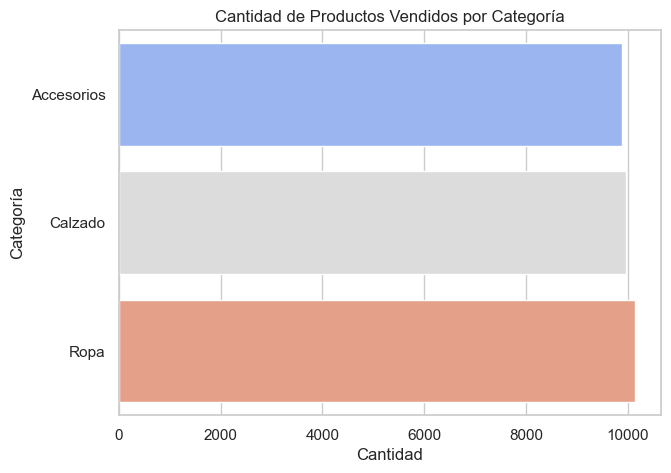

In [24]:

# Cantidad de productos vendidos por categoría (barras horizontales)
plt.figure(figsize=(7,5))
quantity_by_category = df.groupby("product_category")["quantity"].sum().sort_values()
sns.barplot(x=quantity_by_category.values, y=quantity_by_category.index, palette="coolwarm")
plt.title("Cantidad de Productos Vendidos por Categoría")
plt.xlabel("Cantidad")
plt.ylabel("Categoría")
plt.show()


C:\Users\Roberto\AppData\Local\Temp\ipykernel_21100\1045727435.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["purchase_date"] = pd.to_datetime(df["purchase_date"], dayfirst=True)


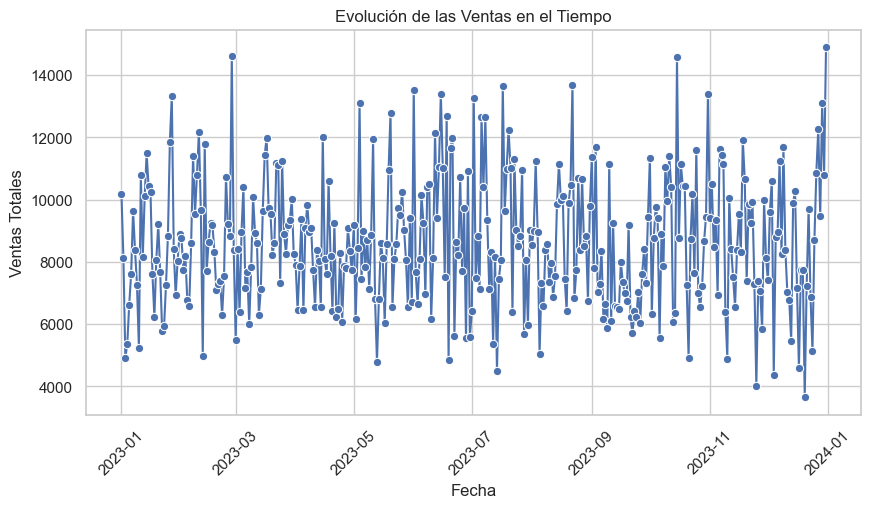

In [25]:
# Evolución de ventas en el tiempo (línea)
df["purchase_date"] = pd.to_datetime(df["purchase_date"], dayfirst=True)
sales_over_time = df.groupby("purchase_date")["order_total"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=sales_over_time, x="purchase_date", y="order_total", marker="o")
plt.title("Evolución de las Ventas en el Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Ventas Totales")
plt.xticks(rotation=45)
plt.show()

C:\Users\Roberto\AppData\Local\Temp\ipykernel_21100\3402675509.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="payment_method", y="order_total", data=df, palette="pastel")


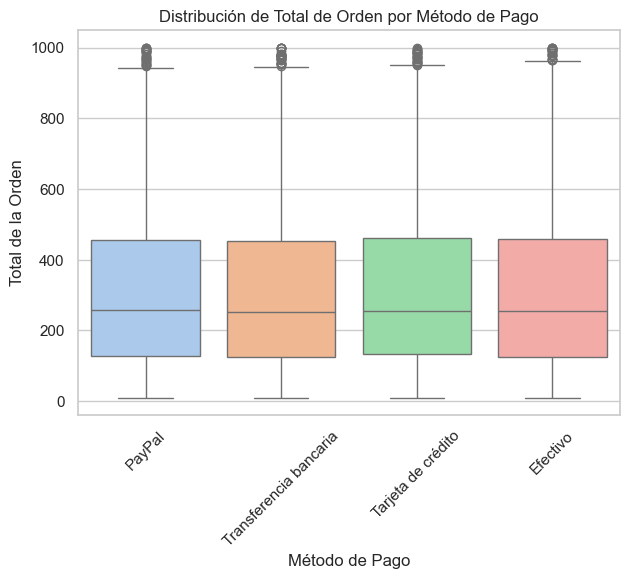

In [26]:
# Distribución de totales de orden por método de pago (boxplot)
plt.figure(figsize=(7,5))
sns.boxplot(x="payment_method", y="order_total", data=df, palette="pastel")
plt.title("Distribución de Total de Orden por Método de Pago")
plt.xlabel("Método de Pago")
plt.ylabel("Total de la Orden")
plt.xticks(rotation=45)
plt.show()

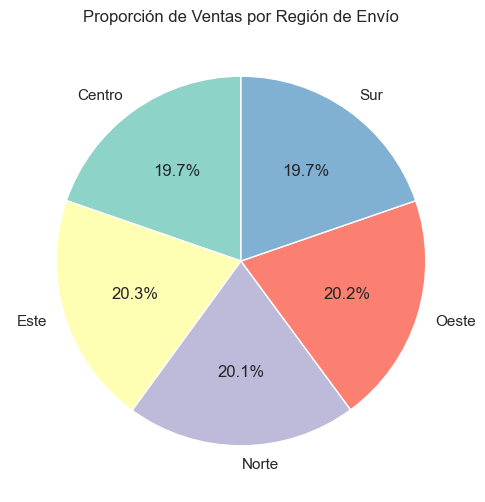

In [27]:
# Proporción de ventas por región de envío (gráfico circular)
plt.figure(figsize=(6,6))
region_sales = df.groupby("shipping_region")["order_total"].sum()
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set3"))
plt.title("Proporción de Ventas por Región de Envío")
plt.show()

# 7. Conclusiones y recomendaciones


### a Conclusiones clave

+  La edad de los clientes no influye en el monto de las compras. 
    La correlación entre edad y total de la orden fue prácticamente nula, lo que indica que las ventas dependen más de otros factores como la categoría de producto o el método de pago, y no de la edad.


+  Las ventas están concentradas en ciertas categorías de productos. 
    Categorías como Ropa y Calzado acumulan una mayor parte de las ventas totales, lo que refleja las preferencias de los clientes y la importancia de mantener un stock adecuado en estas líneas.


+  Los métodos de pago están distribuidos de forma equilibrada. 
    El índice V de Cramer mostró correlación casi nula entre método de pago y categoría de producto. Esto sugiere que los clientes eligen métodos de pago por comodidad personal y no por el tipo de producto.


+  Existen regiones de envío más activas en ventas. 
    Algunas regiones, como Centro y Oeste, concentran un mayor porcentaje de ventas, lo que puede estar relacionado con la densidad poblacional o mayor acceso a internet y medios de pago.